In [2]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os
from tqdm import tqdm
from joblib import Parallel, delayed

In [11]:
#矩阵信息  y方向是格点位置,x方向无限
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m,B,a):
    return (m-4*B/(a**2))*sz

def h_x(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sx

def h_y(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sy

def h_onstie(m,B,a   ,u,Delta,chaodaojiao):
    HX_block=h_k(m,B,a)-u*s0
    Delta_X= 1j *Delta * np.exp(1j*chaodaojiao) *  sy
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])

def t_x(B,a,A):
    TX_block=h_x(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def t_y(B,a,A):
    TX_block=h_y(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def H_onstie(m,B,a   ,u_set,Delta,chaodaojiao,    yshumu,Nd,    A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=h_onstie(m,B,a   ,u_set[i],Delta,chaodaojiao)

        if i < yshumu-1:
            H[i][i+1] = t_y(B,a,A)

        if i > 0:
            H[i][i-1] = t_y(B,a,A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B,a,A,   yshumu,Nd):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=t_x(B,a,A)

    #
    H = np.block(H)
    return H

m=0.5
A=1
B=1  

delta=0.1
chaodaojiao=0
T_Tc=1e-4
Delta = delta* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

a=1
xshumu=21
yshumu=21

uN=0
uS=0
#uS=1

#Ey = 0.0035/yshumu*0.9#
Ey= 0.007/yshumu*0
#Ey=0.0035/10
#Ey=0.003/100
uN_set = []
for i in range(yshumu):
    uN_set.append(uN- Ey*0* (i - yshumu/2))
uS_set=[]
for i in range(yshumu):
    uS_set.append(uS - Ey *1* (i - yshumu/2))
#uS_set=[]
#for i in range(Ny):
#    uS_set.append(uS)
#print(uN_set[99])
#print(uS_set[99])

H_r_x= H_onstie(m,B,a   ,uS_set,Delta,-chaodaojiao,    yshumu,4,    A)
T_r_x= H_hop(B,a,A,   yshumu,4).conj().T

#print(H_q.shape)

Calculating Bands: 100%|██████████| 1501/1501 [00:04<00:00, 311.40it/s]


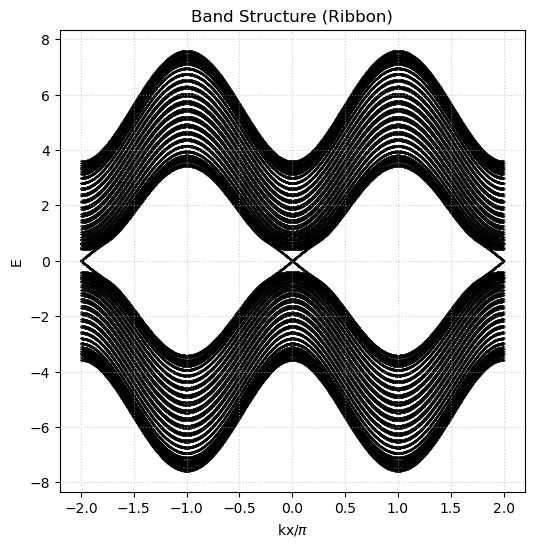

In [ ]:
# x能带
ks1 = np.linspace(-2*np.pi, 2*np.pi, 1501)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies1 = []
# 使用 tqdm 显示进度条
for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_r_x, T_r_x)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 6))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)
#plt.ylim(-0.5,0.5)
#plt.xlim(-0.2,0.2)
plt.xlabel(r'kx/$\pi$')
plt.ylabel('E')
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)

In [12]:
import os
import matplotlib.patches as mpatches # 用于画图例

# ================= 6. 提取 k=0 的本征态并保存 44 分量的分布图 =================

k_target = 0.000*np.pi
# 计算 k 时的哈密顿量
H_k0 = Hk(k_target, H_r_x, T_r_x)

param_folder = f"kx={k_target}_m={m}_A={A}_B={B}_del={delta}_y={yshumu}_uS={uS}_Ey={Ey:.5f}"
save_dir = rf"D:\结果\2026.4.12\{param_folder}"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 求解本征值和本征态
evals, evecs = np.linalg.eigh(H_k0)

Nd = 4  # 你代码里定义的每个格点的自由度维度
print(f"\n开始计算 kx={k_target} 的本征态波函数...")
print(f"共 {len(evals)} 个态，正在保存至 {save_dir} ...")

for i in tqdm(range(len(evals)), desc="Saving Wavefunctions"):
    E = evals[i]
    psi = evecs[:, i] # 提取第 i 个本征态 (长度为 44)
    
    # 计算模方 |psi|^2 (这里不再使用 np.sum 去合并它们)
    prob = np.abs(psi)**2
    
    # 归一化 (总概率之和为1)
    prob = prob / np.sum(prob)
    
    # 画图：把画布拉宽一点，因为要塞下 44 个点
    plt.figure(figsize=(14, 5))
    
    # 定义 4 种颜色：红(e↑), 蓝(e↓), 绿(h↑), 橙(h↓)
    color_map = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e'] 
    
    # 循环生成 44 个柱子的颜色
    colors = [color_map[j % Nd] for j in range(yshumu * Nd)]
    
    # 画柱状图，X轴从 0 到 43
    x_positions = np.arange(yshumu * Nd)
    plt.bar(x_positions, prob, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    # 画垂直的灰色虚线，把第0个格点、第1个格点...隔开，方便眼睛看
    for j in range(yshumu + 1):
        plt.axvline(x=j * Nd - 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # 设置图表标题和坐标轴
    plt.title(f"Detailed 44-Component Probability (k={k_target})\nE = {E:.4f}")
    plt.xlabel("Component Index (0 to 43)")
    plt.ylabel(r"$|\psi|^2$")
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    
    # 设置 X 轴的刻度，显示 0 到 43 所有的数字
    plt.xticks(x_positions, x_positions, fontsize=7)
    plt.xlim(-1, yshumu * Nd)
    #plt.ylim(0, 0.2)
    
    # 制作高逼格的右上角图例 (Legend)
    labels = [r'Electron $\uparrow$ (e_up)', r'Electron $\downarrow$ (e_dn)', 
              r'Hole $\uparrow$ (h_up)', r'Hole $\downarrow$ (h_dn)']
    patches = [mpatches.Patch(color=color_map[k], label=labels[k]) for k in range(Nd)]
    plt.legend(handles=patches, loc='upper right')
    
    # 按能量本征值保留4位小数命名
    filename = f"E_{E:.4f}.png"
    filepath = os.path.join(save_dir, filename)
    
    # 保存并关闭画布
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()

print("全部图片保存完毕！")


开始计算 kx=0.0 的本征态波函数...
共 84 个态，正在保存至 D:\结果\2026.4.12\kx=0.0_m=0.5_A=1_B=1_del=0.1_y=21_uS=0_Ey=0.00000 ...


Saving Wavefunctions: 100%|██████████| 84/84 [00:44<00:00,  1.90it/s]

全部图片保存完毕！


In [ ]:
#矩阵信息  x方向是格点位置,y方向无限
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def h_k(m,B,a):
    return (m-4*B/(a**2))*sz

def h_x(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sx

def h_y(B,a,A):
    return (B/(a**2))*sz-(1j/2)*A*sy

def h_onstie(m,B,a   ,u,Delta,chaodaojiao):
    HX_block=h_k(m,B,a)-u*s0
    Delta_X= 1j *Delta * np.exp(1j*chaodaojiao) *  sy
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])

def t_x(B,a,A):
    TX_block=h_x(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def t_y(B,a,A):
    TX_block=h_y(B,a,A)
    ling_X=np.zeros((2,2))
    return np.block([
        [ TX_block,        ling_X       ],
        [ ling_X.conj().T, -TX_block.conj() ]
    ])

def H_onstie(m,B,a   ,u_set,Delta,chaodaojiao,    yshumu,Nd,    A):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=h_onstie(m,B,a   ,u_set[i],Delta,chaodaojiao)

        if i < yshumu-1:
            H[i][i+1] = t_x(B,a,A)

        if i > 0:
            H[i][i-1] = t_x(B,a,A).conj().T
    
    H = np.block(H)
    return H

def H_hop(B,a,A,   yshumu,Nd):
    Z = np.zeros((Nd, Nd), dtype=complex)
    H = [[Z.copy() for _ in range(yshumu)] for _ in range(yshumu)]

    for i in range(yshumu):
        H[i][i]=t_y(B,a,A)

    #
    H = np.block(H)
    return H

m=0.5
A=1
B=1  

delta=0.1
chaodaojiao=0
T_Tc=1e-4
Delta = delta* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

a=1
xshumu=21
yshumu=21

uS=0
#uS=1
#Ey = 0.0035/yshumu*0.9#
#Ey=0.0035/10
#Ey=0.003/100

uS_set=[]
for i in range(yshumu):
    uS_set.append(uS)
#uS_set=[]
#for i in range(Ny):
#    uS_set.append(uS)
#print(uN_set[99])
#print(uS_set[99])

H_r_y= H_onstie(m,B,a   ,uS_set,Delta,-chaodaojiao,    xshumu,4,    A)
T_r_y= H_hop(B,a,A,   xshumu,4).conj().T

#print(H_q.shape)

Calculating Bands: 100%|██████████| 1501/1501 [00:04<00:00, 301.79it/s]


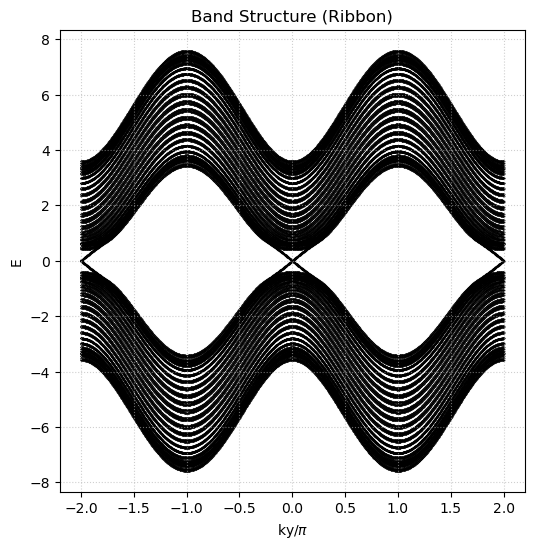

In [ ]:
# y能带
ks1 = np.linspace(-2*np.pi, 2*np.pi, 1501)
def Hk(k, H, T):
    # H(k) = H_onsite + T * exp(-ik) + T.conj().T * exp(ik)
    return H + T * np.exp(-1j * k) + T.conj().T * np.exp(1j * k)

energies1 = []
# 使用 tqdm 显示进度条
for k in tqdm(ks1, desc="Calculating Bands"):
    H_k = Hk(k, H_r_y, T_r_y)
    evals1 = np.linalg.eigvalsh(H_k)
    energies1.append(evals1)

energies1 = np.array(energies1)

plt.figure(figsize=(6, 6))

for i in range(energies1.shape[1]):
    plt.scatter(ks1/np.pi, energies1[:, i], color='black', s=0.1)
#plt.ylim(-0.5,0.5)
#plt.xlim(-0.2,0.2)
plt.xlabel(r'ky/$\pi$')
plt.ylabel('E')
plt.title('Band Structure (Ribbon)')
plt.grid(True, linestyle=':', alpha=0.6)